# Läpimenoajan minimointi työpajassa PROC OPTMODEL -proseduurilla


## Tiivistelmä

Pienen kappaletuotantosolun on ajettava neljä osaa — **Kannatin** (Bracket), **Laippa** (Flange), **Kotelo** (Housing) ja **Akseli** (Shaft) — kukin kiinteän kolmen työstöoperaation sarjan läpi, jakaen neljä yksikkökapasiteetin konetta (**Saha**, **Jyrsin**, **Pora**, **Hionta**). Mikään kone ei voi ajaa kahta operaatiota yhtä aikaa, ja kunkin osan operaatioiden on noudatettava teknologista järjestystään. Muotoilemme läpimenoaikaa minimoivan aikataulun sekalukuoptimointitehtävänä **PROC OPTMODEL** -proseduurissa — alkuaikamuuttujat, lopetus-alkamis-järjestysrajoitteet ja disjunktiiviset (big-*M*) ei-päällekkäisyysrajoitteet jokaisen konetta jakavan operaatioparin välillä — ja ratkaisemme sen todistettuun optimaalisuuteen.

MILP-ratkaisija palauttaa **optimaalisen läpimenoajan 120 minuuttia** (`Solution Status = Optimal`, `Objective Value = 120`). Tuloksena syntyvä aikataulu pakkaa kaikki kaksitoista operaatiota niin, että jokainen kone käsittelee korkeintaan yhtä osaa kerrallaan ja jokainen osa työstetään vaaditussa teknologisessa järjestyksessään. Kaksi operaatiota päättyy täsmälleen minuutilla 120 — Kannattimen hionta ja Kotelon jyrsintä — joten sekä Hionta- että Jyrsin-kone ovat kriittisellä polulla, joka määrää aikataulun pituuden.

## Tietolähteet

Kaikki data on määritelty muistikirjan sisällä — ei ulkoisia tiedostoja eikä verkkoa.

| Aineisto | Rivit | Avainmuuttujat | Kuvaus |
|---------|------|---------------|-------------|
| `jobshop` | 12 | `op`, `job`, `opnum`, `machine`, `dur`, `jobname`, `mname` | Yksi rivi operaatiota kohti (4 osaa × 3 operaatiota). `machine` (1–4) on kone, jota operaatio tarvitsee; `dur` on sen käsittelyaika minuutteina; `jobname`/`mname` ovat luettavat osa- ja koneselitteet. |
| `sched` | 12 | `op`, `start`, `finish` | OPTMODELin tuloste: kunkin operaation optimaalinen alkamis- ja lopetusminuutti. |
| `schedule` | 12 | `jobname`, `opnum`, `mname`, `dur`, `start`, `finish` | `jobshop` yhdistettynä ratkaistuihin aikoihin, lajiteltuna koneen ja sitten alkamisen mukaan — ihmisluettava aikataulu. |
| `mk` | 1 | `makespan` | Toteutunut läpimenoaika (viimeisin lopetusaika). |

## Aikataulutusongelma

**Työpajassa** (job shop) useat osat ("työt") kulkevat kukin kiinteän operaatiosarjan läpi, ja jokainen operaatio ajetaan tietyllä koneella. Kaksi operaatiota ei voi olla samalla koneella samaan aikaan (koneet ovat *unaarisia* resursseja), ja osan sisällä operaatioiden on kunnioitettava teknologista järjestystään. Suunnittelija haluaa kullekin operaatiolle alkuajat, jotka noudattavat molempia sääntöjä pitäen samalla kokonaisaikataulun pituuden — **läpimenoajan** — mahdollisimman pienenä.

Tämä on klassinen disjunktiivinen aikataulutusongelma. Mallinnamme sen sekalukuoptimointitehtävänä:

- jatkuva-mutta-kokonaisluku-**alkuaika** `s[o]` kullekin operaatiolle sekä läpimenoaikamuuttuja `Cmax`;
- **järjestys**: osan operaatio *k+1* alkaa aikaisintaan silloin, kun operaatio *k* päättyy;
- **disjunktiivinen konekapasiteetti**: jokaiselle konetta jakavalle operaatioparille binäärimuuttuja `y` päättää kumpi menee ensin, ja big-*M*-termi kytkee pois epäaktiivisen järjestyksen — joten kaksi operaatiota ei voi koskaan olla päällekkäin;
- **tavoite**: minimoi `Cmax`, joka pakotetaan olemaan vähintään jokaisen operaation lopetusajan suuruinen.

PROC OPTMODEL on SAS/OR:n algebrallinen mallinnusproseduuri; sen MILP-ratkaisija löytää *todistettavasti optimaalisen* lyhimmän aikataulun.

> **Huomautus PROC CLP:stä.** SAS tarjoaa myös PROC CLP:n, > rajoite-logiikkaohjelmoinnin (constraint-logic programming) moottorin, jossa on omistettu > aikataulutussyntaksi (aktiviteetit, resurssit, järjestys). Tässä käytetty OPTMODELin MILP-muotoilu ratkaisee > saman ongelman ja palauttaa optimaalisuustodistuksen, jota CLP:n > käyvyyshaku ei tuota.

## Vaihe 1 — Määrittele pajan tilanne

Neljä osaa, kolme operaatiota kutakin, neljällä koneella. Kukin rivi kiinnittää koneen, jota operaatio tarvitsee, ja sen käsittelyajan minuutteina. Osan operaatiot on listattu teknologisessa järjestyksessä (`opnum` 1, 2, 3).

In [1]:
TIEDOT jobshop;
    PITUUS jobname $10 mname $8;
    SYÖTE op job opnum machine dur jobname $ mname $;
    DATALINES;
1  1 1 1 25 Kannatin Saha
2  1 2 3 40 Kannatin Pora
3  1 3 4 20 Kannatin Hionta
4  2 1 2 35 Laippa   Jyrsin
5  2 2 3 25 Laippa   Pora
6  2 3 1 15 Laippa   Saha
7  3 1 3 30 Kotelo   Pora
8  3 2 1 20 Kotelo   Saha
9  3 3 2 45 Kotelo   Jyrsin
10 4 1 1 20 Akseli   Saha
11 4 2 2 30 Akseli   Jyrsin
12 4 3 4 25 Akseli   Hionta
;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=jobshop NIMIKE noobs;
    OTSIKKO 'Työpajan tilanne: 4 osaa, 3 operaatiota kutakin, 4 konetta';
    MUUTTUJA op jobname opnum mname dur;
    NIMIKE op="Operaatio" jobname="Osa" opnum="Vaihe" mname="Kone" dur="Kesto (min)";
SUORITA;

                               Työpajan tilanne: 4 osaa, 3 operaatiota kutakin, 4 konetta                               

Operaatio       Osa  Vaihe    Kone  Kesto (min)
        1  Kannatin      1  Saha             25
        2  Kannatin      2  Pora             40
        3  Kannatin      3  Hionta           20
        4  Laippa        1  Jyrsin           35
        5  Laippa        2  Pora             25
        6  Laippa        3  Saha             15
        7  Kotelo        1  Pora             30
        8  Kotelo        2  Saha             20
        9  Kotelo        3  Jyrsin           45
       10  Akseli        1  Saha             20
       11  Akseli        2  Jyrsin           30
       12  Akseli        3  Hionta           25




NOTE: DATA jobshop

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote jobshop (12 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=jobshop

NOTE: PROC PRINT completed: 12 observations printed, 5 variables


## Vaihe 2 — Ratkaise läpimenoaikaa minimoiva aikataulu PROC OPTMODEL -proseduurilla

OPTMODEL lukee tilanteen, rakentaa alkuaika- ja järjestysmuuttujat, asettaa järjestys- ja disjunktiiviset rajoitteet ja minimoi läpimenoajan MILP-ratkaisijallaan. Big-*M*-horisontti `H` on työsisällön kokonaismäärä — turvallinen yläraja mille tahansa alkuajalle. Ratkaisija raportoi **optimaalisen** tavoitearvon; kirjoitamme valitut alkamis- ja lopetusajat aineistoon `sched`.

In [2]:
PROSEDUURI optmodel;
    ASETA OPS;
    num job{OPS};
    num opnum{OPS};
    num machine{OPS};
    num dur{OPS};
    READ TIEDOT jobshop INTO OPS=[op] job opnum machine dur;

    /* turvallinen big-M-horisontti = työsisällön kokonaismäärä */
    num H = sum{o SISÄLLÄ OPS} dur[o];

    MUUTTUJA s{OPS} >= 0 integer;     /* operaation alkuaika (minuuttia) */
    MUUTTUJA Cmax >= 0;               /* läpimenoaika */

    /* teknologinen järjestys: operaatio k+1 alkaa operaation k päätyttyä */
    con prec{a SISÄLLÄ OPS, b SISÄLLÄ OPS:
             job[a] = job[b] AND opnum[b] = opnum[a] + 1}:
        s[b] >= s[a] + dur[a];

    /* läpimenoaika dominoi jokaisen operaation lopetusaikaa */
    con span{o SISÄLLÄ OPS}: Cmax >= s[o] + dur[o];

    /* disjunktiivinen konekapasiteetti: kullekin konetta jakavalle
       operaatioparille binäärimuuttuja y kiinnittää järjestyksen; big-M
       löysentää epäaktiivisen järjestyksen */
    MUUTTUJA y{a SISÄLLÄ OPS, b SISÄLLÄ OPS:
          a < b AND machine[a] = machine[b]} binary;
    con seqAB{a SISÄLLÄ OPS, b SISÄLLÄ OPS:
              a < b AND machine[a] = machine[b]}:
        s[b] >= s[a] + dur[a] - H * (1 - y[a,b]);
    con seqBA{a SISÄLLÄ OPS, b SISÄLLÄ OPS:
              a < b AND machine[a] = machine[b]}:
        s[a] >= s[b] + dur[b] - H * y[a,b];

    impvar FINISH{o SISÄLLÄ OPS} = s[o] + dur[o];

    MIN makespan = Cmax;
    solve WITH milp;

    CREATE TIEDOT sched FROM
        [op]={o SISÄLLÄ OPS}
        START=s[o] FINISH=FINISH[o];
QUIT;

                               Työpajan tilanne: 4 osaa, 3 operaatiota kutakin, 4 konetta                               


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            MAKESPAN
  Objective Type                Linear

  Number of Variables           157
  Bounded Above                 0
  Bounded Below                 13
  Bounded Below and Above       144
  Free                          0
  Fixed                         0

  Number of Constraints         46
  Integer Variables             156

                          Solution Summary
  Solver                        MILP
  Objective Function            MAKESPAN
  Solution Status               Optimal
  Objective Value               120.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Vaihe 3 — Kokoa luettava aikataulu

Yhdistä ratkaistut ajat takaisin osa- ja koneselitteisiin, lajittele koneen ja sitten alkamisajan mukaan, ja tulosta aikataulu. Läpimenoaika on suurin lopetusaika kaikkien operaatioiden yli.

In [3]:
PROSEDUURI LAJITTELE TIEDOT=jobshop out=jobs2; MUKAAN op; SUORITA;
PROSEDUURI LAJITTELE TIEDOT=sched   out=sol;   MUKAAN op; SUORITA;

TIEDOT schedule;
    YHDISTÄ jobs2 sol;
    MUKAAN op;
SUORITA;

PROSEDUURI LAJITTELE TIEDOT=schedule; MUKAAN mname START; SUORITA;

PROSEDUURI TULOSTA TIEDOT=schedule NIMIKE noobs;
    OTSIKKO 'Optimaalinen aikataulu: kunkin operaation alku/loppu (minuuttia)';
    MUUTTUJA jobname opnum mname dur START FINISH;
    NIMIKE jobname="Osa" opnum="Vaihe" mname="Kone" dur="Kesto (min)"
          START="Alku (min)" FINISH="Loppu (min)";
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=schedule MAX NOPRINT;
    MUUTTUJA FINISH;
    TULOSTE out=mk(POISTA=_type_ _freq_) MAX=makespan;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=mk NIMIKE noobs;
    OTSIKKO 'Minimiläpimenoaika (viimeisin operaation lopetus, minuuttia)';
    NIMIKE makespan="Läpimenoaika (min)";
SUORITA;

                            Optimaalinen aikataulu: kunkin operaation alku/loppu (minuuttia)                            

     Osa  Vaihe    Kone  Kesto (min)  Alku (min)  Loppu (min)
Akseli        3  Hionta           25          65           90
Kannatin      3  Hionta           20         100          120
Laippa        1  Jyrsin           35           0           35
Akseli        2  Jyrsin           30          35           65
Kotelo        3  Jyrsin           45          75          120
Kotelo        1  Pora             30           0           30
Laippa        2  Pora             25          35           60
Kannatin      2  Pora             40          60          100
Akseli        1  Saha             20           0           20
Kannatin      1  Saha             25          20           45
Kotelo        2  Saha             20          45           65
Laippa        3  Saha             15          65           80

                              Minimiläpimenoaika (viimeisin operaation 


NOTE: PROC SORT data=jobshop

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from jobshop.
NOTE: Wrote jobs2 (12 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from sched.
NOTE: Wrote sol (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA schedule

NOTE: Stream 1 processed 12 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 12 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=schedule

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from schedule.
NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=schedule

NOTE: PROC PRINT completed: 12 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: Output dataset 

## Vaihe 4 — Visualisoi aikataulu

Annamme kullekin operaatiolle järjestysluvun **paikan** (lajiteltuna koneen ja sitten alkamisen mukaan) ja piirrämme sen aikaikkunan kelluvana palkkina: palkki ulottuu operaation alkamisminuutista sen lopetusminuuttiin. Paikat 1–2 ovat Hionta, 3–5 Jyrsin, 6–8 Pora ja 9–12 Saha. Suoraan alla oleva taulukko nimeää osan kussakin paikassa, joten kaavio ja taulukko luetaan yhdessä. Saman koneen palkit eivät koskaan mene ajallisesti päällekkäin — disjunktiivinen rajoite tehtynä näkyväksi.

                          Aikataulu paikoittain (paikkajärjestys vastaa alla olevaa kaaviota)                           

Paikka    Kone       Osa  Alku (min)  Loppu (min)
     1  Hionta  Akseli            65           90
     2  Hionta  Kannatin         100          120
     3  Jyrsin  Laippa             0           35
     4  Jyrsin  Akseli            35           65
     5  Jyrsin  Kotelo            75          120
     6  Pora    Kotelo             0           30
     7  Pora    Laippa            35           60
     8  Pora    Kannatin          60          100
     9  Saha    Akseli             0           20
    10  Saha    Kannatin          20           45
    11  Saha    Kotelo            45           65
    12  Saha    Laippa            65           80

                          Aikataulu paikoittain (paikkajärjestys vastaa alla olevaa kaaviota)                           




NOTE: DATA ganttdata


NOTE: Read 12 rows from schedule.
NOTE: Wrote ganttdata (12 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ganttdata

NOTE: PROC PRINT completed: 12 observations printed, 5 variables
NOTE: PROC SGPLOT data=ganttdata

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


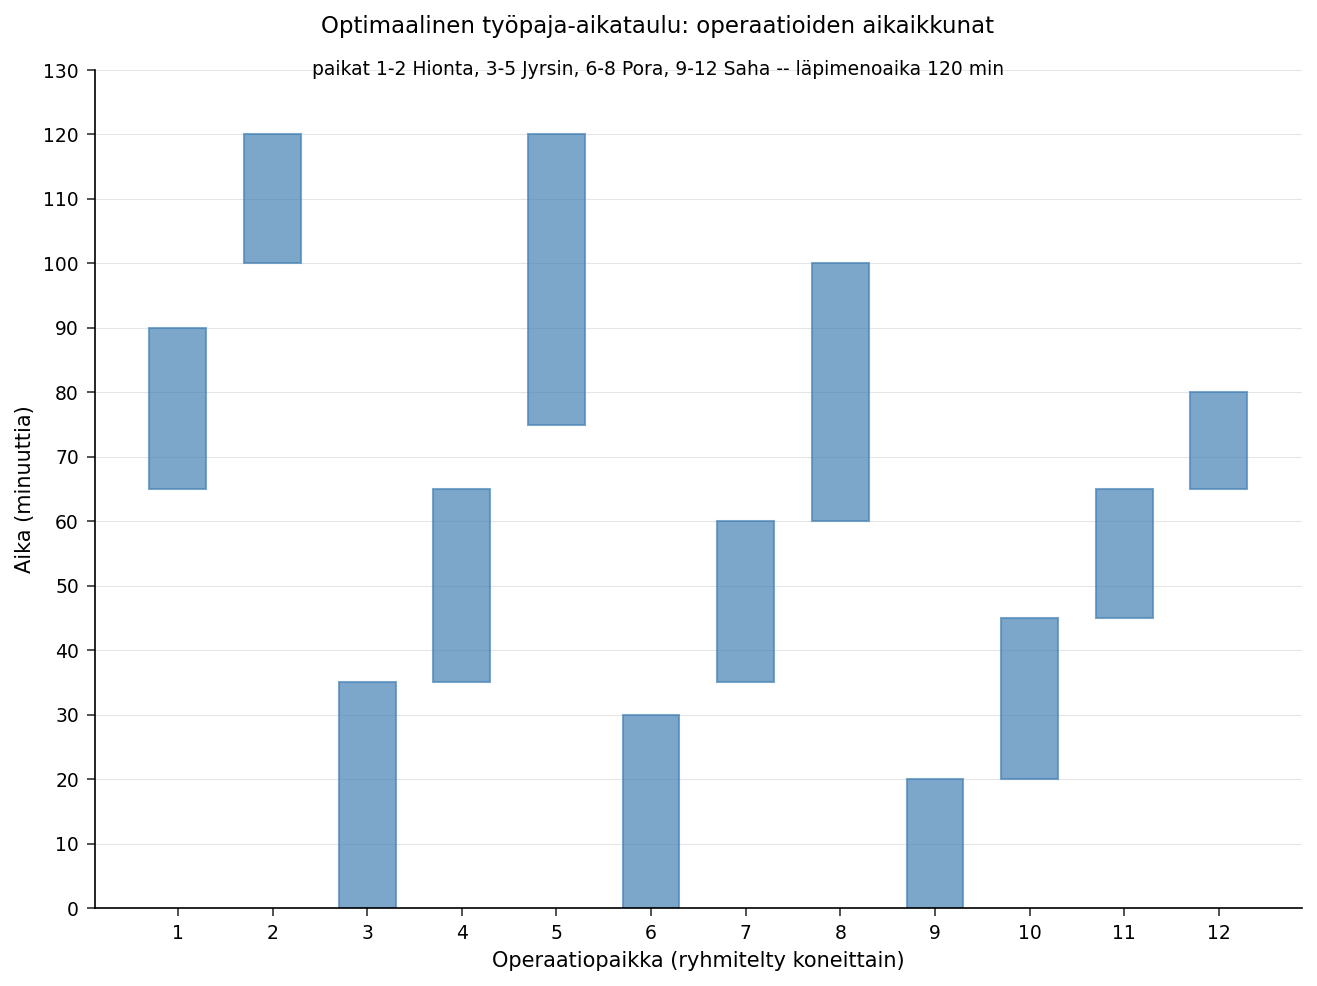

In [4]:
TIEDOT ganttdata;
    ASETA schedule;
    slot + 1;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=ganttdata NIMIKE noobs;
    OTSIKKO 'Aikataulu paikoittain (paikkajärjestys vastaa alla olevaa kaaviota)';
    MUUTTUJA slot mname jobname START FINISH;
    NIMIKE slot="Paikka" mname="Kone" jobname="Osa" START="Alku (min)" FINISH="Loppu (min)";
SUORITA;

PROSEDUURI SGPLOT TIEDOT=ganttdata noautolegend;
    OTSIKKO 'Optimaalinen työpaja-aikataulu: operaatioiden aikaikkunat';
    title2 'paikat 1-2 Hionta, 3-5 Jyrsin, 6-8 Pora, 9-12 Saha -- läpimenoaika 120 min';
    highlow x=slot HIGH=FINISH LOW=START / type=bar barwidth=0.65
            fillattrs=(color=steel) LINEATTRS=(color=navy);
    XAXIS NIMIKE='Operaatiopaikka (ryhmitelty koneittain)' integer
          VALUES=(1 ASTI 12 MUKAAN 1);
    YAXIS NIMIKE='Aika (minuuttia)' grid VALUES=(0 ASTI 130 MUKAAN 10);
SUORITA;
OTSIKKO;

## Tulosten tulkinta

- **Optimaalisuus.** MILP-ratkaisija palautti `Solution Status = Optimal` arvolla `Objective Value = 120`, joten **120 minuuttia on todistettavasti lyhin mahdollinen läpimenoaika** tälle tilanteelle — mikään aikataulu ei voi valmistua aikaisemmin. Tämä todistus on se, minkä matemaattisen ohjelmoinnin muotoilu tarjoaa puhtaan käyvyyshaun sijaan.

- **Aikataulu kunnioittaa jokaista rajoitetta.** Konekohtaista taulukkoa lukien mitkään kaksi saman koneen operaatiota eivät ole päällekkäin (esim. Sahalla: Akseli 0–20, Kannatin 20–45, Kotelo 45–65, Laippa 65–80), ja kukin osa ajetaan teknologisessa järjestyksessä (esim. Kotelo: Pora 0–30, sitten Saha 45–65, sitten Jyrsin 75–120). Kelluvan palkin kaavio näyttää saman: kunkin koneen paikkakaistan sisällä aikaikkunat asettuvat vieretysten ilman törmäyksiä.

- **Mikä määrää aikataulun pituuden.** Kaksi operaatiota päättyy täsmälleen minuutilla 120 — Kannattimen hionta (paikka 2) ja Kotelon jyrsintä (paikka 5). Molemmat koskettavat läpimenoaikaa, joten Hionta- ja Jyrsin-koneet sijaitsevat kriittisellä polulla; läpimenoajan lyhentäminen edelleen vaatisi itse tilanteen muuttamista (nopeammat operaatiot, ylimääräinen kone tai löysennetty järjestys), ei pelkkää uudelleenjärjestämistä.

- **Kuinka se skaalautuu.** Muotoilu kasvaa luontevasti: lisää kone `machine`-muuttujan uutena arvona, lisää osia lisärivinä aineistoon `jobshop`, tai mallinna vapautus- ja eräpäivät rajaamalla `s[o]`:ta ja lisäämällä eräpäivärajoitteita. Sen salliminen, että kone ajaa useita töitä kerralla (kapasiteetti >1), korvaa parittaisen disjunktion kumulatiivisella resurssirajoitteella. Sama OPTMODELin MILP käsittelee tällöin rikkaampia tuotantolattian sääntöjä ratkaisijaa muuttamatta.